# 03 — Evaluation & Inference
**Team:** Langrangers

| Name | USN |
|---|---|
| Aaron Thomas Mathew | PES1UG23AM005 |
| Aman Kumar Mishra | PES1UG23AM040 |
| Preetham VJ | PES1UG23AM913 |

**Model:** [aaronmat1905/Qwen2VL-finetuned-chartqa](https://huggingface.co/aaronmat1905/Qwen2VL-finetuned-chartqa)  
**Base Model:** [Qwen/Qwen2-VL-2B-Instruct](https://huggingface.co/Qwen/Qwen2-VL-2B-Instruct)  
**Dataset:** [HuggingFaceM4/ChartQA](https://huggingface.co/datasets/HuggingFaceM4/ChartQA)

This notebook:
1. Pulls the fine-tuned LoRA adapters from HuggingFace
2. Merges adapters with the base model
3. Evaluates on the ChartQA test split using Relaxed Accuracy
4. Shows qualitative inference examples

In [1]:
pip install huggingface_hub

Note: you may need to restart the kernel to use updated packages.


## 1. Install Dependencies

In [2]:
!pip install -q transformers peft bitsandbytes accelerate datasets pillow matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.0 MB/s eta 0:00:00:00:0100:01


## 2. Imports & Config

In [3]:
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel
from datasets import load_dataset
from PIL import Image
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
import gc

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
ADAPTER_REPO  = "aaronmat1905/Qwen2VL-finetuned-chartqa"
ADAPTER_SUBFOLDER = "best"
DATASET_ID    = "HuggingFaceM4/ChartQA"

MIN_PIXELS = 256 * 28 * 28
MAX_PIXELS = 512 * 28 * 28
MAX_NEW_TOKENS = 64
EVAL_SAMPLES = 50  # set to None to run on full test split (2500 samples, ~1.5hrs)

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 3. Load Model — Pull Adapters from HuggingFace & Merge

**Why merge?**  
LoRA adapters add small `A` and `B` matrices alongside each target weight. At inference time, merging folds `W_new = W_base + (B @ A) * (alpha/rank)` into a single weight matrix. This eliminates the overhead of computing adapter outputs at every forward pass, giving faster inference with identical outputs.

In [5]:
# Load base model in 8-bit (keeps VRAM under 15.6 GB on T4)
bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0,
    llm_int8_has_fp16_weight=False
)

print("Loading base model...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

print("Loading LoRA adapters from HuggingFace...")
model = PeftModel.from_pretrained(model, ADAPTER_REPO, subfolder="best")

print("Merging adapters into base model...")
model = model.merge_and_unload()  # folds adapter weights into base — faster inference
model.eval()

processor = AutoProcessor.from_pretrained(
    BASE_MODEL_ID,
    min_pixels=MIN_PIXELS,
    max_pixels=MAX_PIXELS
)

print("\nModel ready!")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

Loading base model...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loading LoRA adapters from HuggingFace...


/usr/local/lib/python3.12/dist-packages/peft/peft_model.py:598: UserWarning: Found missing adapter keys while loading the checkpoint: ['base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.language_model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.language_model.layers.0.self_attn.k_proj.lora_A.default.weight', 'base_model.model.model.language_model.layers.0.self_attn.k_proj.lora_B.default.weight', 'base_model.model.model.language_model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.language_model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.language_model.layers.0.self_attn.o_proj.lora_A.default.weight', 'base_model.model.model.language_model.layers.0.self_attn.o_proj.lora_B.default.weight', 'base_model.model.model.language_model.layers.1.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.language_model.layers.1.self_attn.q_proj

Merging adapters into base model...

Model ready!
Total parameters: 2.21B


## 4. Load ChartQA Test Split

In [6]:
dataset = load_dataset(DATASET_ID)
test_data = dataset["test"]

if EVAL_SAMPLES:
    test_data = test_data.select(range(EVAL_SAMPLES))

print(f"Evaluating on {len(test_data)} test samples")

README.md:   0%|          | 0.00/852 [00:00<?, ?B/s]

data/train-00000-of-00003-49492f364babfa(…):   0%|          | 0.00/219M [00:00<?, ?B/s]

data/train-00001-of-00003-7302bae5e425bb(…):   0%|          | 0.00/311M [00:00<?, ?B/s]

data/train-00002-of-00003-194c9400785577(…):   0%|          | 0.00/315M [00:00<?, ?B/s]

data/val-00000-of-00001-0f11003c77497969(…):   0%|          | 0.00/50.2M [00:00<?, ?B/s]

data/test-00000-of-00001-e2cd0b7a0f9eb20(…):   0%|          | 0.00/68.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/28299 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1920 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Evaluating on 50 test samples


## 5. Inference Helper

In [7]:
def run_inference(model, processor, image, question, max_new_tokens=64):
    """
    Run a single inference pass.
    Returns the model's raw answer string.
    """
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": question}
        ]
    }]

    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = processor(
        text=[text], images=[image], return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens)

    decoded = processor.decode(output[0], skip_special_tokens=True)
    # Extract only the assistant's response
    answer = decoded.split("assistant")[-1].strip()

    del inputs, output
    gc.collect()
    torch.cuda.empty_cache()

    return answer

print("Inference helper defined.")

Inference helper defined.


## 6. Evaluation — Relaxed Accuracy

ChartQA uses **Relaxed Accuracy** as its standard metric:
- For **numeric** answers: predicted and ground-truth values are considered correct if they are within **5% of each other**
- For **text** answers: exact string match (case-insensitive, stripped)

This tolerates minor rounding differences in numeric chart values.

In [8]:
def relaxed_accuracy(prediction: str, ground_truth: str, tolerance: float = 0.05) -> bool:
    """
    ChartQA relaxed accuracy metric.
    - Numeric: correct if |pred - gt| / |gt| <= tolerance (5%)
    - Text: case-insensitive exact match
    """
    pred = prediction.strip().lower()
    gt   = ground_truth.strip().lower()

    # Try numeric comparison first
    try:
        pred_val = float(pred.replace(",", ""))
        gt_val   = float(gt.replace(",", ""))
        if gt_val == 0:
            return pred_val == 0
        return abs(pred_val - gt_val) / abs(gt_val) <= tolerance
    except ValueError:
        pass

    # Fallback: text exact match
    return pred == gt

print("Relaxed accuracy function defined.")

Relaxed accuracy function defined.


In [9]:
results = []
correct = 0

print(f"Running evaluation on {len(test_data)} samples...")
print("(This may take a while on T4 — ~1.5s/sample)\n")

for i, sample in enumerate(tqdm(test_data)):
    image = sample["image"]
    query = sample["query"]
    label = sample["label"]

    # label can be a list
    if isinstance(label, list):
        label = label[0]
    label = str(label).strip()

    prediction = run_inference(model, processor, image, query, MAX_NEW_TOKENS)

    is_correct = relaxed_accuracy(prediction, label)
    if is_correct:
        correct += 1

    results.append({
        "idx": i,
        "query": query,
        "label": label,
        "prediction": prediction,
        "correct": is_correct,
        "human_or_machine": sample.get("human_or_machine", None)
    })

    if (i + 1) % 20 == 0:
        running_acc = correct / (i + 1) * 100
        print(f"  [{i+1}/{len(test_data)}] Running accuracy: {running_acc:.1f}%")

final_accuracy = correct / len(results) * 100
print(f"\n{'='*40}")
print(f"  Relaxed Accuracy: {final_accuracy:.2f}%")
print(f"  Correct: {correct}/{len(results)}")
print(f"{'='*40}")

Running evaluation on 50 samples...
(This may take a while on T4 — ~1.5s/sample)



 40%|████      | 20/50 [01:42<01:35,  3.18s/it]

  [20/50] Running accuracy: 15.0%


 80%|████████  | 40/50 [03:10<01:05,  6.57s/it]

  [40/50] Running accuracy: 12.5%


100%|██████████| 50/50 [03:46<00:00,  4.53s/it]


  Relaxed Accuracy: 18.00%
  Correct: 9/50


## 7. Accuracy by Human vs Machine Split

ChartQA contains both human-authored questions (harder, more reasoning-heavy) and machine-generated questions (simpler, more data lookup). Breaking down accuracy by this split gives a clearer picture of model capability.

Overall Relaxed Accuracy : 18.00%
Human questions accuracy : 18.00%  (n=50)
Machine questions accuracy: 0.00%  (n=0)


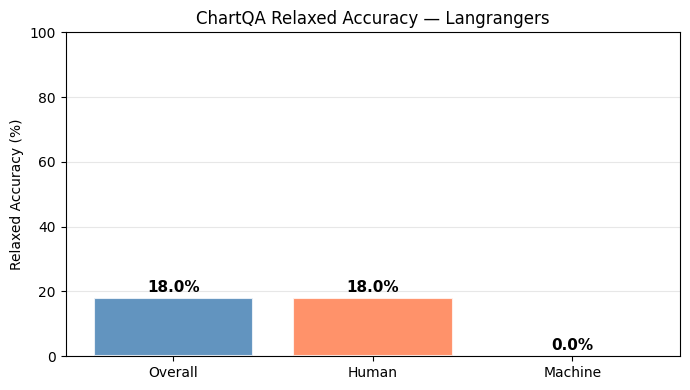

Saved to /content/accuracy_breakdown.png


In [10]:
human_results  = [r for r in results if str(r["human_or_machine"]) == "0"]
machine_results = [r for r in results if str(r["human_or_machine"]) == "1"]

def acc(result_list):
    if not result_list:
        return 0.0
    return sum(r["correct"] for r in result_list) / len(result_list) * 100

print(f"Overall Relaxed Accuracy : {final_accuracy:.2f}%")
print(f"Human questions accuracy : {acc(human_results):.2f}%  (n={len(human_results)})")
print(f"Machine questions accuracy: {acc(machine_results):.2f}%  (n={len(machine_results)})")

# Bar chart
categories = ["Overall", "Human", "Machine"]
values     = [final_accuracy, acc(human_results), acc(machine_results)]
colors     = ["steelblue", "coral", "mediumseagreen"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(categories, values, color=colors, alpha=0.85, edgecolor="white", linewidth=1.5)
ax.set_ylim(0, 100)
ax.set_ylabel("Relaxed Accuracy (%)")
ax.set_title("ChartQA Relaxed Accuracy — Langrangers")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/content/accuracy_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to /content/accuracy_breakdown.png")

## 8. Qualitative Examples — Correct Predictions

/tmp/ipykernel_55/194219825.py:16: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/194219825.py:17: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/correct_examples.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


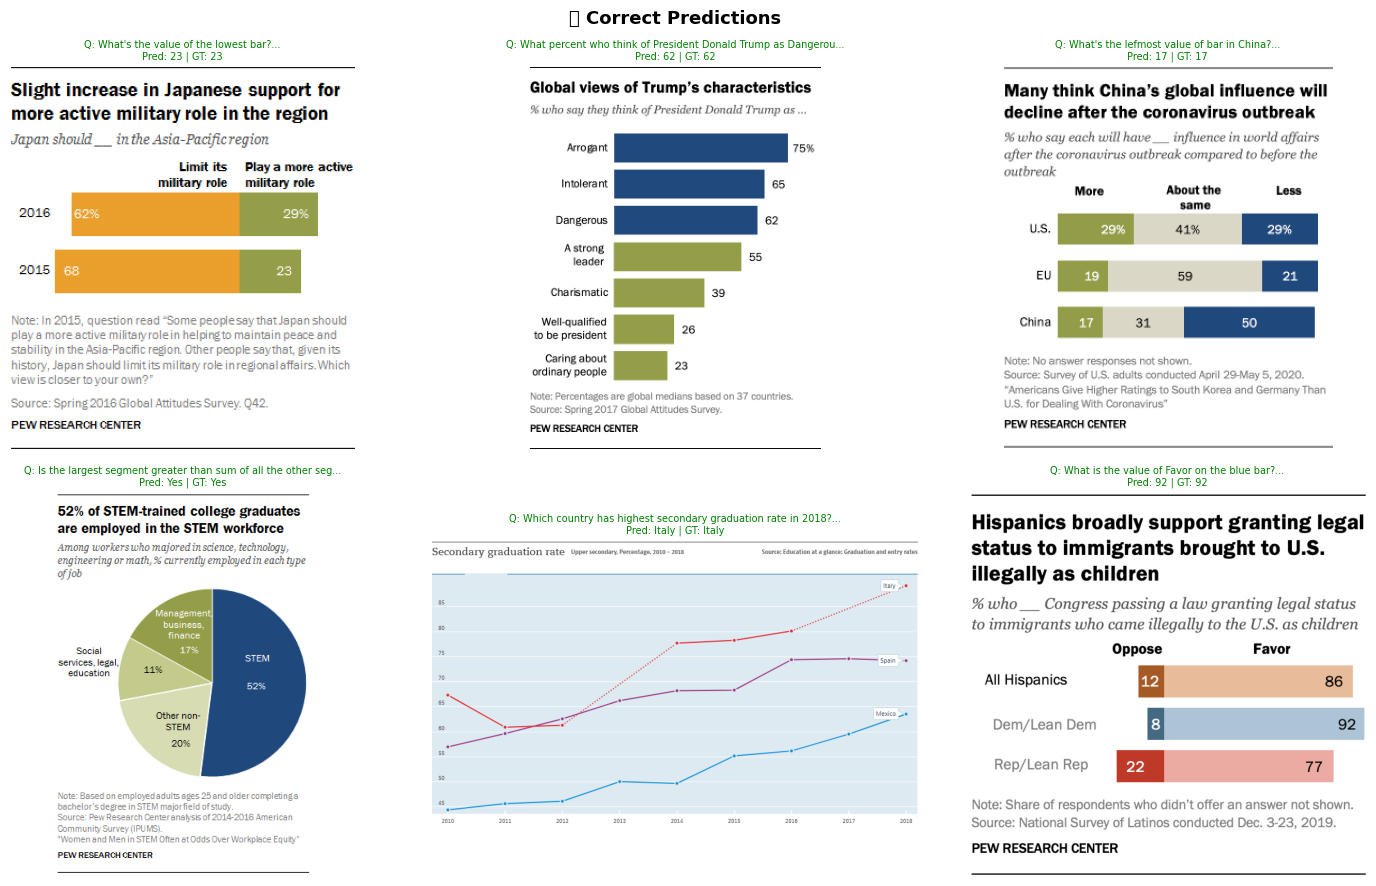

Saved to /content/correct_examples.png


In [11]:
correct_examples = [r for r in results if r["correct"]][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, ex in enumerate(correct_examples):
    sample = test_data[ex["idx"]]
    axes[i].imshow(sample["image"])
    axes[i].axis("off")
    axes[i].set_title(
        f"Q: {ex['query'][:60]}...\nPred: {ex['prediction'][:30]} | GT: {ex['label']}",
        fontsize=7, color="green"
    )

plt.suptitle("✅ Correct Predictions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/correct_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to /content/correct_examples.png")

## 9. Qualitative Examples — Incorrect Predictions

/tmp/ipykernel_55/1581220986.py:16: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1581220986.py:17: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/wrong_examples.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


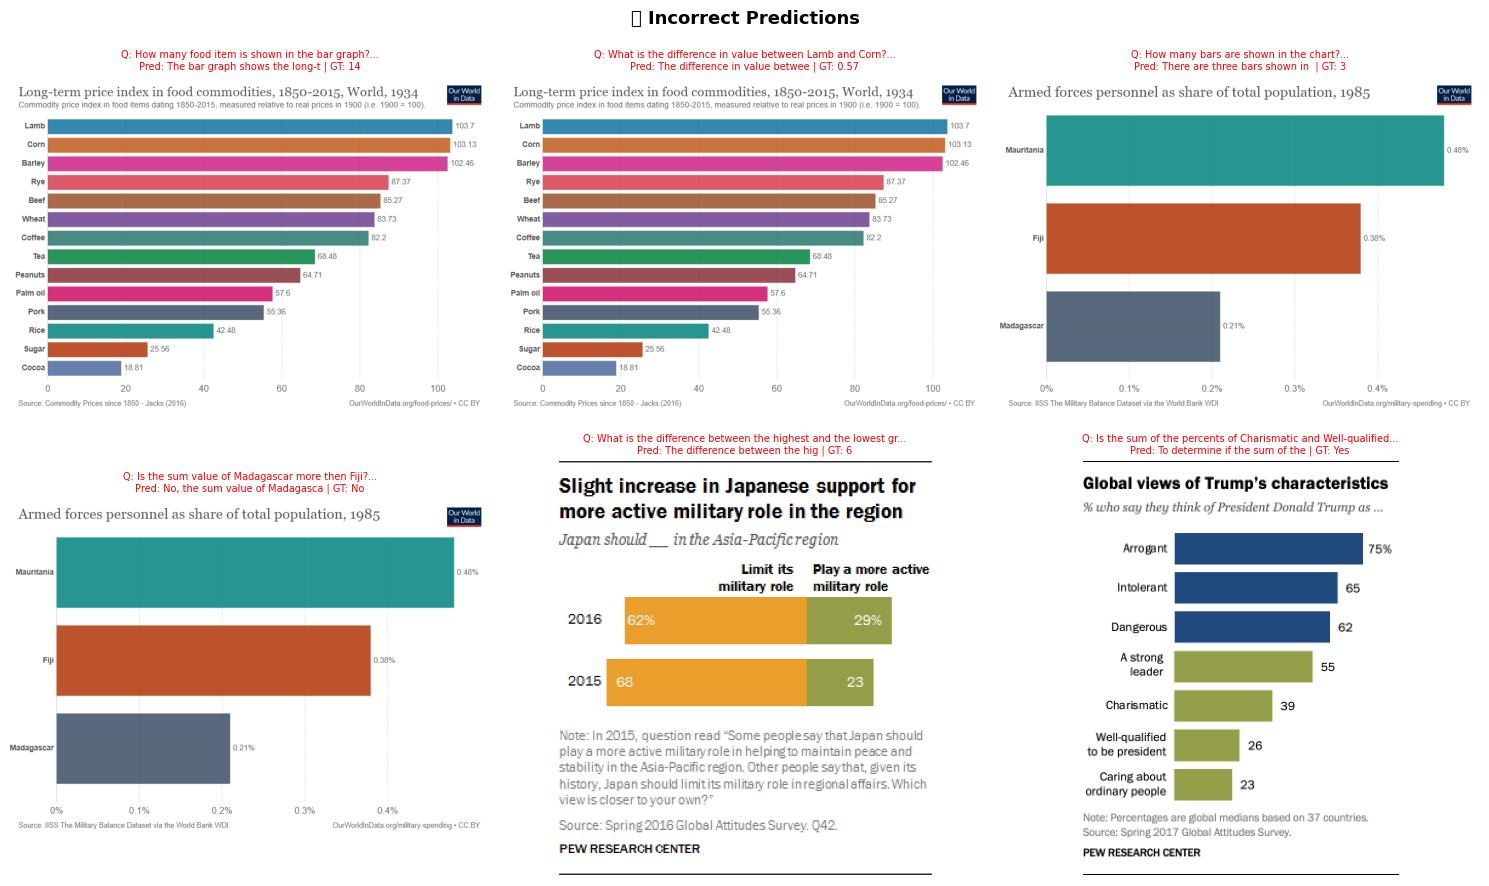

Saved to /content/wrong_examples.png


In [12]:
wrong_examples = [r for r in results if not r["correct"]][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, ex in enumerate(wrong_examples):
    sample = test_data[ex["idx"]]
    axes[i].imshow(sample["image"])
    axes[i].axis("off")
    axes[i].set_title(
        f"Q: {ex['query'][:60]}...\nPred: {ex['prediction'][:30]} | GT: {ex['label']}",
        fontsize=7, color="red"
    )

plt.suptitle("❌ Incorrect Predictions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/wrong_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to /content/wrong_examples.png")

## 10. Single Interactive Inference

Run a single chart + question of your choice.

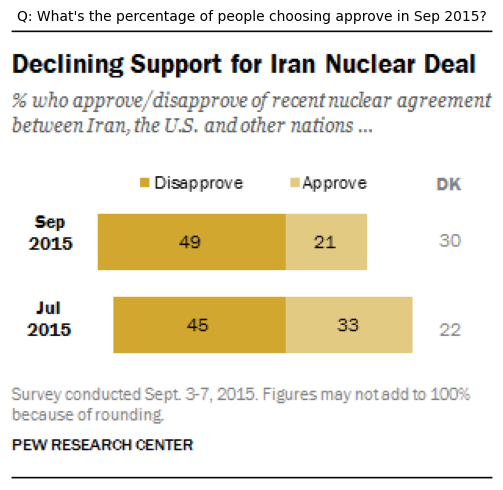

Question   : What's the percentage of people choosing approve in Sep 2015?
Ground Truth: 21
Prediction : 21
Correct    : True


In [13]:
# Pick any sample from the test set
idx = 42
sample = dataset["test"][idx]

image    = sample["image"]
question = sample["query"]
gt_label = sample["label"]
if isinstance(gt_label, list):
    gt_label = gt_label[0]

prediction = run_inference(model, processor, image, question)

plt.figure(figsize=(7, 5))
plt.imshow(image)
plt.axis("off")
plt.title(f"Q: {question}", fontsize=10)
plt.tight_layout()
plt.show()

print(f"Question   : {question}")
print(f"Ground Truth: {gt_label}")
print(f"Prediction : {prediction}")
print(f"Correct    : {relaxed_accuracy(prediction, gt_label)}")

## 11. Summary

In [15]:
print("="*50)
print("  EVALUATION SUMMARY — Langrangers")
print("="*50)
print(f"  Model         : aaronmat1905/Qwen2VL-finetuned-chartqa")
print(f"  Base Model    : Qwen2-VL-2B-Instruct")
print(f"  Dataset       : HuggingFaceM4/ChartQA")
print(f"  Test samples  : {len(results)}")
print(f"  Correct       : {correct}")
print(f"  Relaxed Acc.  : {final_accuracy:.2f}%")
print(f"  Human Acc.    : {acc(human_results):.2f}%")
print(f"  Machine Acc.  : {acc(machine_results):.2f}%")
print("="*50)

  EVALUATION SUMMARY — Langrangers
  Model         : aaronmat1905/Qwen2VL-finetuned-chartqa
  Base Model    : Qwen2-VL-2B-Instruct
  Dataset       : HuggingFaceM4/ChartQA
  Test samples  : 50
  Correct       : 9
  Relaxed Acc.  : 18.00%
  Human Acc.    : 18.00%
  Machine Acc.  : 0.00%
